<a href="https://colab.research.google.com/github/EssenceBL/HPMparticipation/blob/main/The_Ming_Catalan_Numbers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The name that can be named is not the enduring and unchanging name.

-- Tao Te Ching, Laozi

Definitions belong to the definers, not the defined.

-- Toni Morrison

### Background

Naming the same thing in different ways can signal a shift in perspective — a kind of translation that emphasizes conceptual transformation. Through such differences, one strieves to explore the true underlying nature. In mathematics, the Ming-Catalan numbers or the Catalan numbers, for example, can be defined from multiple perspectives, each leading to essentially the same entity. Transformations between these perspectives can be ideally explained through Colab exercises. This notebook thus expands the base established in earlier work; in other words, it's a continuation on the series' mission of bridging mathematics and programming.

--YK with DeepSeek, 2025-2026

Like other Colab notebooks, please run the code cells in sequence. In particular, the following code cell handles the dependency package and must be run first.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
import time
from IPython.display import clear_output
from ipywidgets import interact, IntSlider
from IPython.display import display
import ipywidgets as widgets
from ipywidgets import interactive

### Listing Dyck words

One definition of the **Ming–Catalan number** of order $n$ is the number of Dyck words of length $2n$; here, a Dyck word is a binary word of length $2n$ consisting of $n$ copies of one letter, say U, and $n$ copies of another, say R, such that for any positive $m ≤ 2n$, among the first $m$ letters, the number of U appearing is no less than that of R.

Please run the following code cell to see the list of Dyck words of length $2n$ for some small $n$. Often, more knowledge is required to produce than to comprehend; the combinatorial algorithm for listing follows from Knuth’s work in *The Art of Computer Programming*.



In [ ]:

def dyck_words(n):
  # Initialize base word: 0101...01 of length 2n
  X = ['U' if i % 2 == 0 else 'R' for i in range(2 * n)]
  wordString = ''.join(X)
  yield wordString  # Visit initial word
  def generate(X, k):
    wordString = ''.join(X)
    i = k
    while i < 2 * n - 1:
      # Find first occurrence of "UR" (was "10") starting from position i
      j = None
      for pos in range(i, 2 * n - 1):
        if X[pos] == 'R' and X[pos + 1] == 'U':
          j = pos
          break
      if j is None:
        break
      # Create copy Y
      Y = X.copy()
      # Swap U and R (change UR to RU)
      Y[j], Y[j + 1] = Y[j + 1], Y[j]
      # Visit new word
      yield ''.join(Y)
      i = j + 2
      # Recursive call with j-1
      yield from generate(Y, j - 1)
  # First call with k=1
  yield from generate(X, 1)

def display_dyck_words(n):
  #start_time = time.time()
  #print("Timer started!")
  count = 0
  words = list(dyck_words(n))
  print(f"n={n}: {len(words)} word(s)")
  for word in words:
    count += 1
    print(f"{count}. {word}")
  print()
  #elapsed_time = time.time() - start_time
  #print(f"Time taken: {elapsed_time:.2f} seconds")
  print("-" * 55)


# Create the interactive widget and capture it in a variable
widget = interact(display_dyck_words,
         n=IntSlider(value=3, min=0, max=9, step=1,
                    description='n:',
                    continuous_update=False))


# This will show only the slider, not the function output
output = widgets.Output()


### Dyck word as a name for valid path

One way to visualize a Dyck word of length $2n$ is to map it to a valid path of length $2n$ on an $n×n$ grid orginated from bottom left to top right, moving only north and east, and being valid in the sense that the path should not cross the dotted line with slope $1$ and $x-$intercept $1$. The validity condition directly translates to the requirement that “among the first $m$ letters, the number of U appearing is no less than that of R for any positive $m ≤ 2n$.” Please run the following cell to align your understanding with the illustrations.

In [ ]:
def draw_grid(ax, rows, cols, title, diagonal_start, diagonal_end):
    # Draw horizontal lines
    for i in range(rows+1):
        ax.plot([0, cols],
            [i , i],
            '-', color='grey', alpha=0.7)

    # Draw vertical lines
    for j in range(cols+1):
        ax.plot([j, j],
            [0, rows],
            '-', color='grey', alpha=0.7)

    # Draw diagonal line (extend a bit beyond the grid)
    ax.plot([diagonal_start[0]-0.2, diagonal_end[0]+0.2],
            [diagonal_start[1]-0.2, diagonal_end[1]+0.2],
            '--', color='blue', alpha=0.7)

    ax.set_xlim(-0.5, cols + 0.5)
    ax.set_ylim(-0.5, rows + 0.5)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.grid(False)

def draw_path(ax, path, start_pos=(0, 0), color = 'blue'):
    x, y = start_pos
    positions = [(x, y)]

    # Draw each step of the path
    for move in path:
        if move == 'U':
            # Draw upward arrow
            ax.arrow(x, y, 0, 1, head_width=0.1, head_length=0.1,
                    fc=color, ec=color, linewidth=2)
            y += 1
        else:
            # Draw rightward arrow
            ax.arrow(x, y, 1, 0, head_width=0.1, head_length=0.1,
                    fc=color, ec=color, linewidth=2)
            x += 1
        positions.append((x, y))

    return positions


def draw_valid(n, path_str):
  fig, ax = plt.subplots(figsize=(3, 3))
  path = list(path_str)
  pathStr = ''.join(path)
  draw_grid(ax, n, n, f'{pathStr}', (1, 0), (n, n-1))
  draw_path(ax, path)
  plt.tight_layout()
  plt.show()
  return

def dyck_words(n):
  # Initialize base word: 0101...01 of length 2n
  X = ['U' if i % 2 == 0 else 'R' for i in range(2 * n)]
  wordString = ''.join(X)
  yield wordString  # Visit initial word
  def generate(X, k):
    wordString = ''.join(X)
    draw_valid(n, X)
    i = k
    while i < 2 * n - 1:
      # Find first occurrence of "UR" (was "10") starting from position i
      j = None
      for pos in range(i, 2 * n - 1):
        if X[pos] == 'R' and X[pos + 1] == 'U':
          j = pos
          break
      if j is None:
        break
      # Create copy Y
      Y = X.copy()
      # Swap U and R (change UR to RU)
      Y[j], Y[j + 1] = Y[j + 1], Y[j]
      # Visit new word
      yield ''.join(Y)
      i = j + 2
      # Recursive call with j-1
      yield from generate(Y, j - 1)
  # First call with k=1
  yield from generate(X, 1)

# Create the interactive widget and capture it in a variable
widget = interact(display_dyck_words,
         n=IntSlider(value=3, min=0, max=5, step=1,
                    description='n:',
                    continuous_update=False))


# This will show only the slider, not the function output
output = widgets.Output()


### From paths to associations

Another definition of the Ming–Catalan number of order $n$ is the number of ways to associate $n$ applications of a binary operator to $n+1$ distinct factors. In our convention, we use the letters a, b, c, … to name these factors for some small $n$.

To check the equivalence of the two definitions, we will define two functions in our custom convention. The first function, **PathToAssociation**, maps any Dyck word to an association. The second function, **AssociationToPath**, maps any association to a Dyck word. It is easy to verify that the two functions are inverses of each other. We begin with the first function.

Given any Dyck word of length $2n$, we prepare a cursor '_' and $n+1$ factors: a, b, c, … The function **PathToAssociation** processes an input Dyck word sequentially. Start with the cursor in its initial position. If the next letter is 'U', replace the cursor with a pair of parentheses containing the cursor '( _ )' —this is our canonical way to open a new bracket. If the next letter is 'R', replace the cursor with the next factor, then check whether there is a position on the right awaiting completion of a binary association (i.e., an open leaf in the rooted tree of binary operations); if so, move the cursor there; otherwise, all binary associations are complete and we have reached the function output.

We can simply see this function in action in the following cell:


In [ ]:
def PathToAssociation(pathStr):
  n = len(pathStr)//2 + 1
  pathStr_read = ''
  pathStr_unread = pathStr
  variableUsed = ''
  variablesRemain = 'abcdefghijklmnopqrstuvwxyz'
  current = '_'
  for i, char in enumerate(pathStr):
    pathStr_read += char
    pathStr_unread = pathStr_unread.replace(char, '', 1)
    if char == "U":
      current = current.replace('_', '(_)')
      print("U: ", current)
    elif char == "R":
      pos = current.find('_')
      current = current.replace('_', variablesRemain[0]+'_')
      pos += 1
      variableUsed += variablesRemain[0]

      for k in range(2,len(variableUsed)+1):
        #print('pos', pos)
        #print('k', k)
        if k == 2:
          check = pos-2
          #print('check',check)
          if current[check] == '(':
            #print('not moving', current)
            break
          elif current[check] in ')abcdefghijklmnopqrstuvwxyz':
            current = current[:pos] + ')_' + current[pos+2:]
            pos += 1
            #print('moving', current)
        else:
          checkS = list(range(pos - 3 - 2, -1, -3))
          #print('checkS', checkS)
          indices = [i for i, char in enumerate(current) if char == '(' and i in checkS]
          #print('indices',indices)
          balancing = [current[index+1:pos].count('(') - current[index+1:pos].count(')') for index in indices]
          #print('balancing',balancing)
          if 0 in balancing:
            #print('not moving', current)
            break
          else:
            current = current[:pos] + ')_' + current[pos+2:]
            pos += 1
            #print('moving', current)
      print("R: ", current)
      variablesRemain = variablesRemain[1:]
  current = current.replace('_', variablesRemain[0])
  variablesRemain = variablesRemain[1:]
  print("Path to association: ", pathStr, "->", current, '\n')
  return current

def list_association(n):
  # Initialize base word: 0101...01 of length 2n
  X = ['U' if i % 2 == 0 else 'R' for i in range(2 * n)]
  wordString = ''.join(X)
  yield wordString  # Visit initial word
  def generate(X, k):
    wordString = ''.join(X)
    PathToAssociation(wordString)
    i = k
    while i < 2 * n - 1:
      # Find first occurrence of "UR" (was "10") starting from position i
      j = None
      for pos in range(i, 2 * n - 1):
        if X[pos] == 'R' and X[pos + 1] == 'U':
          j = pos
          break
      if j is None:
        break
      # Create copy Y
      Y = X.copy()
      # Swap U and R (change UR to RU)
      Y[j], Y[j + 1] = Y[j + 1], Y[j]
      # Visit new word
      yield ''.join(Y)
      i = j + 2
      # Recursive call with j-1
      yield from generate(Y, j - 1)
  # First call with k=1
  yield from generate(X, 1)

def display_associations(n):
  #start_time = time.time()
  #print("Timer started!")
  count = 0
  paths_to_associations = list(list_association(n))
  #elapsed_time = time.time() - start_time
  #print(f"Time taken: {elapsed_time:.2f} seconds")
  print("-" * 55)


# Create the interactive widget and capture it in a variable
widget = interact(display_associations,
         n=IntSlider(value=3, min=0, max=9, step=1,
                    description='n:',
                    continuous_update=False))


# This will show only the slider, not the function output
output = widgets.Output()


### From associations to paths

The reverse direction, constructing **AssociationToPath**, is even simpler. Given any association with $n+1$ canonical factors a, b, c, …, the function processes the association as a string, i.e. a sequence of characters. There are only three cases to handle: an open bracket '(', a factor, or a closed bracket ')'. If '(' is read, append 'U' to the output; if a factor is read, append 'R'; if ')' is read, do nothing. The closing bracket can be ignored because its information is recoverable from the opening brackets and factors in binary associations. In this convention, the first character must be '(', so the output always starts with 'U'. Moreover, valid associations naturally yield valid paths.

Have fun with the following cell!


In [ ]:
def AssociationToPath(parathesis):
  variables = 'abcdefghijklmnopqrstuvwxyz'
  countU = 0
  countR = 0
  countClose = 0
  path = ''
  for i, char in enumerate(parathesis):
    if char == '(':
      path = path + 'U'
      countU += 1
    elif char == variables[0]:
      countR += 1
      if countR > countU:
        countR = countU
        break
      path = path + 'R'
      variables = variables.replace(char, '')
    elif char == ')':
      countClose += 1
    else:
      print("Your input is not valid, please do it again")
      break
  if countU == countR:
    return path
  else:
    return

# @title Try with your own assoication, only valid ones would run through
while True:
  # Print the input first
  testassociation = input("Try with your assoication with alphabet a, b, c, d, e..., \n using ( and ) to indicate each and every composition, \n for example (a(b(c(((de)(f((gh)i)))j)))): \n")
  # Try to convert with error handling
  try:
    path = AssociationToPath(testassociation)
    if path:
      print('Association: ', testassociation)
      print('Corresponding valid path: ', path)
      draw_valid(len(path)//2, path)
      break  # Exit the loop when we get a valid output
  except:
    print("Please check your input; something is not working.")

### Counting the Ming-Catalan numbers

We are now ready to consolidate the counting of the Ming–Catalan numbers. Knowing that counting associations for $n+1$ factors is the same as counting Dyck words or valid paths of length $2n$, we denote this number by $C_n$. Among all $C^{2n}_n$ paths that move only north and east orginated from the bottom left to the top right of an $n×n$ grid, we ask how many of them hit the dashed line. For these “hypo” paths, one can perform a reflection in the dashed line starting from the first hitting point; this yields a one-to-one correspondence with paths orginated from the bottom left to the top right of an $(n+1)×(n-1)$ grid. There are $C^{2n}_{n-1}$ of them to be ignored. This final twist gives us the exact lens to distinguish between the desired valid paths and those "hypo" paths. We are now ready to consolidate a counting of the Ming–Catalan numbers $C_{n} = C^{2n}_{n} - C^{2n}_{n-1} = \frac{C^{2n}_n}{n+1}$.

![picture](https://drive.google.com/uc?id=1X_cz60yLw1ImXZJDARfSNIo_x75YeZ3v)

### Echoing in this local HPM group:
### Some history of me on this topic besides the above programmable pedagogy

- Coincides with toolkits I made to benchmark the standard time needed on constructing one STEM case study.

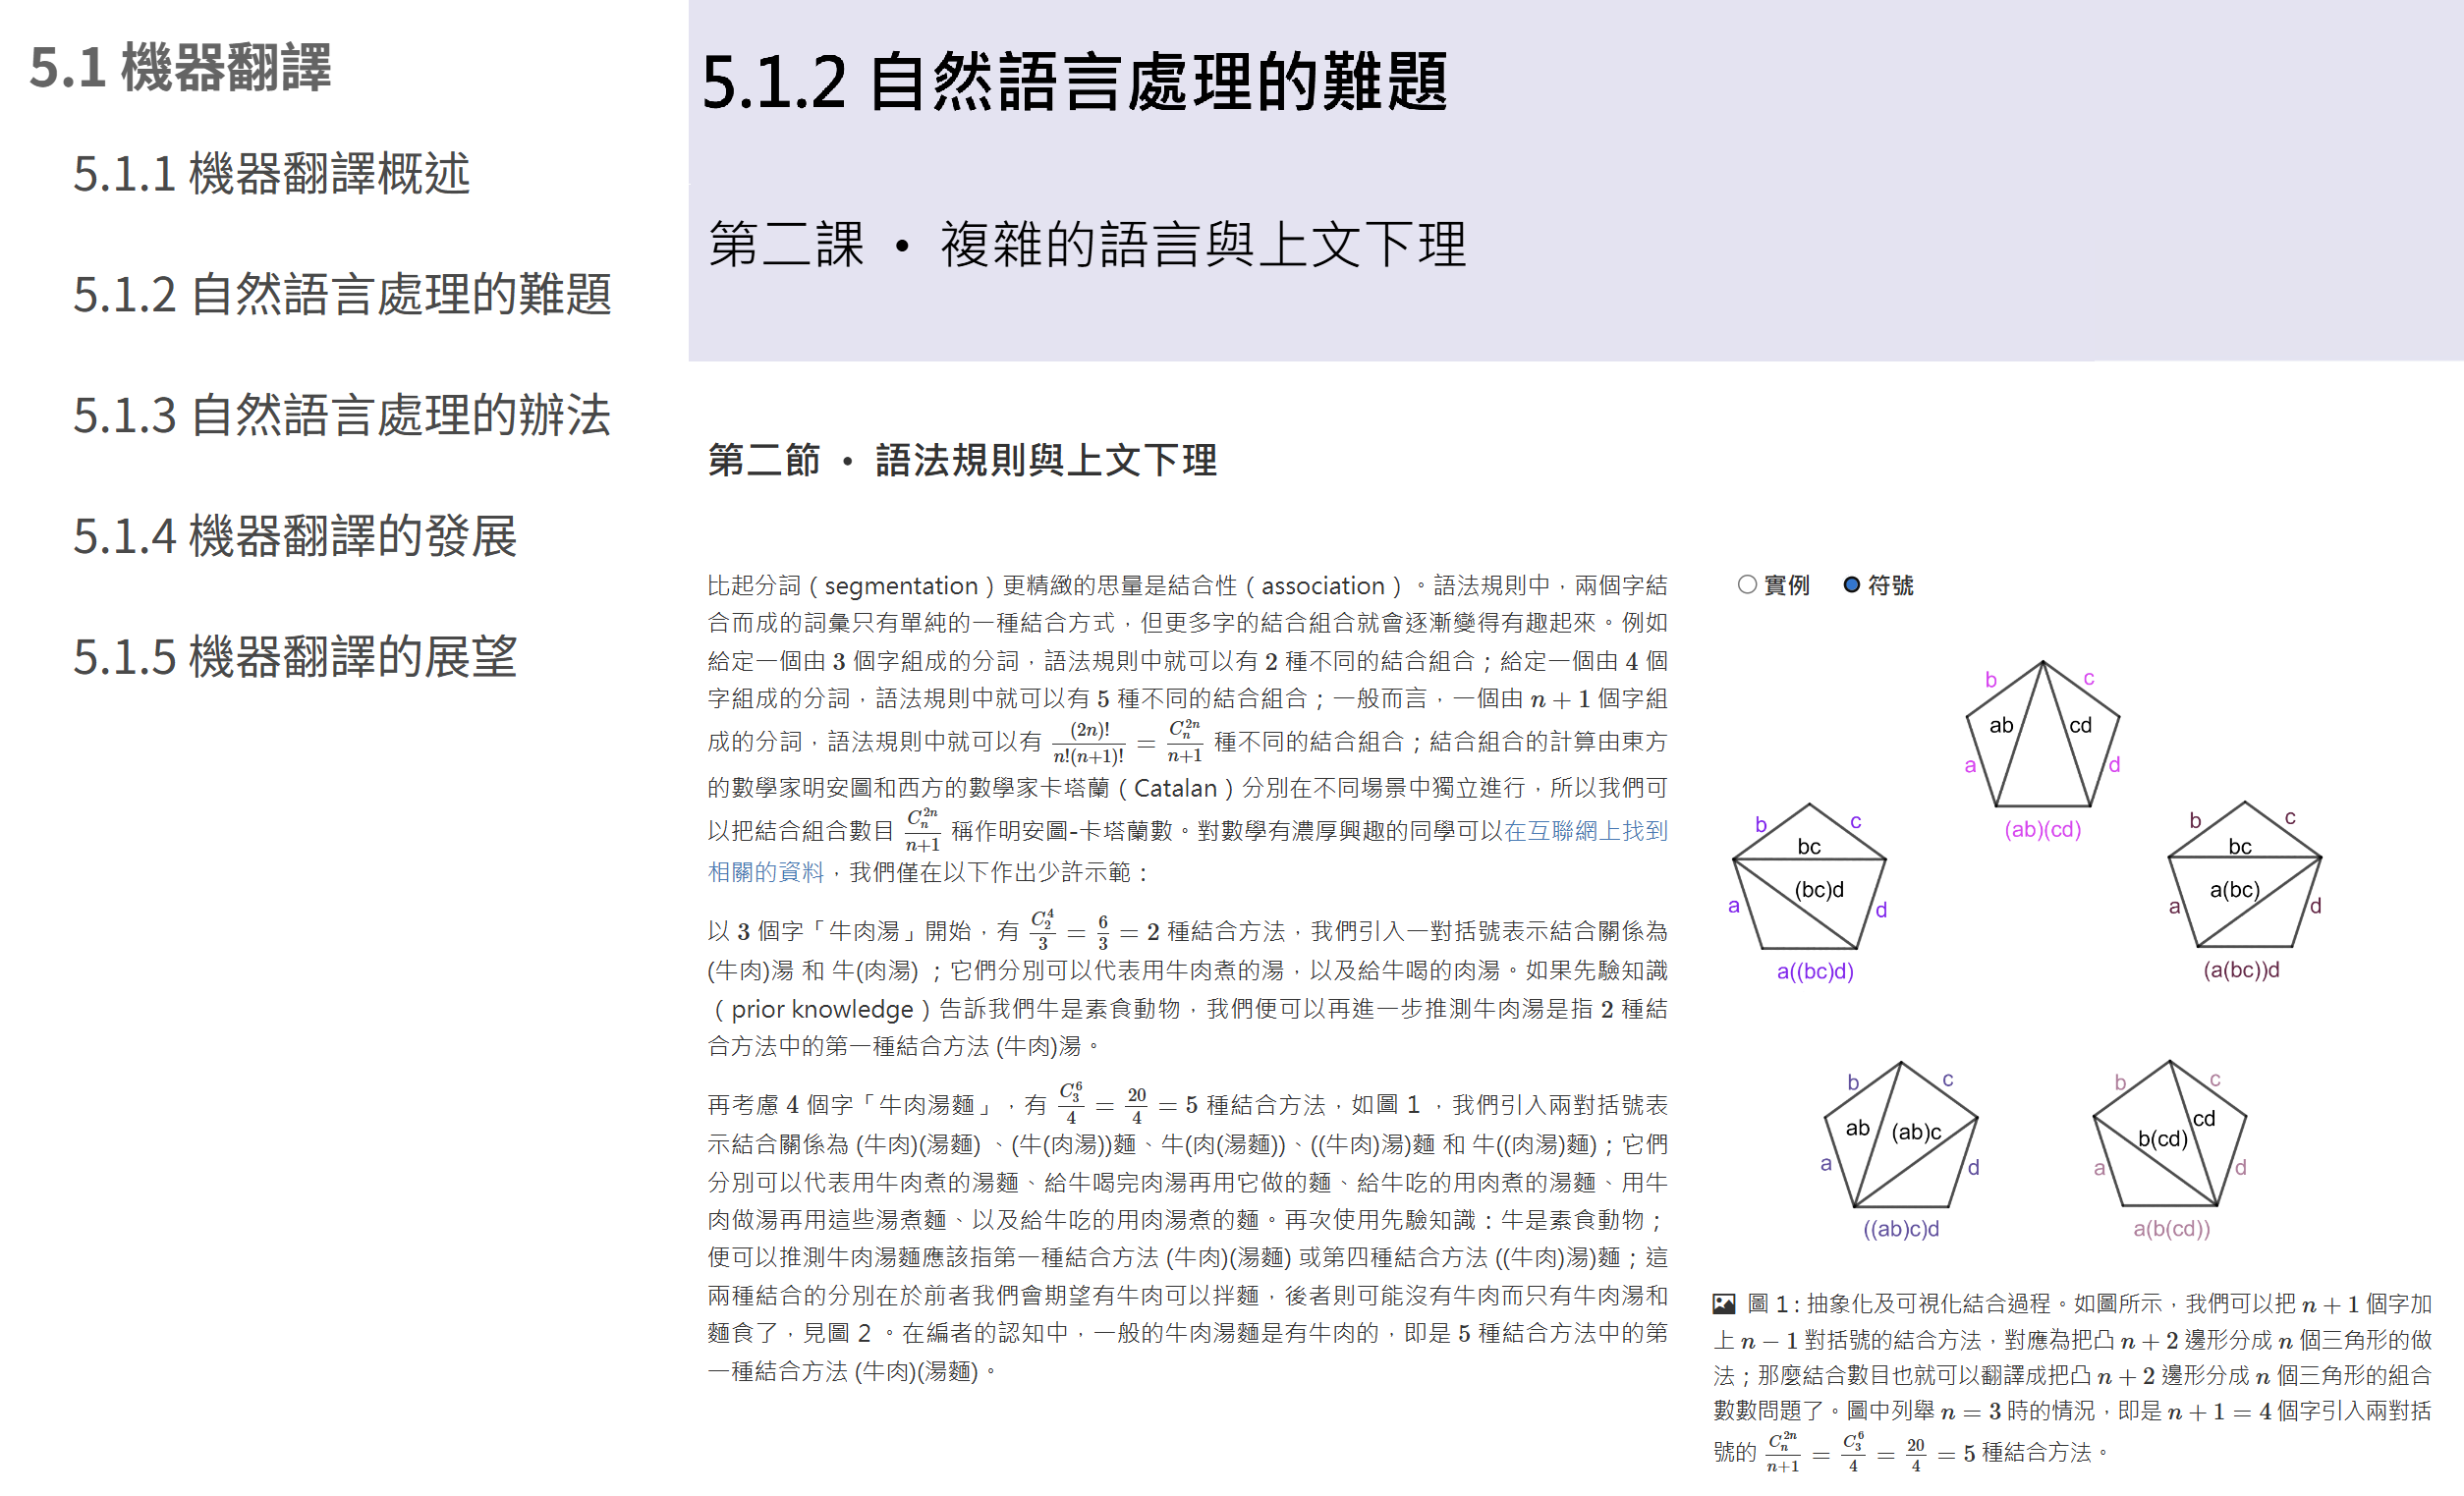

  (with some subtle differences in convention, this particular toolkit was made in 2023, YK)

- Coincides with a series of [workshops](https://github.com/EssenceBL/MakingFriends) connecting mathematics and programming, always in collaboration.
